# Fraud Detection — Preprocessing, Baseline Modeling & Evaluation

Loads the processed data from `01_eda.ipynb`, trains three baseline classifiers under class imbalance, and evaluates them with imbalance-appropriate metrics.

**Critical discipline:** split the data *before* any scaling or resampling, to avoid leakage.

## 1. Load Processed Data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")

d = pd.read_csv("../data/processed/fraud_processed.csv")
print(d.shape)
d.head()

(277510, 11)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,isFullDrain
0,132,CASH_OUT,215489.19,21518.00,0.0,6345756.55,6794954.89,0,-193971.19,-2.337091e+05,0
1,135,CASH_OUT,214026.20,46909.73,0.0,13467450.36,13681476.56,0,-167116.47,-1.862645e-09,0
2,381,CASH_OUT,8858.45,0.00,0.0,1667180.58,1676039.03,0,-8858.45,0.000000e+00,0
3,347,CASH_OUT,120989.98,0.00,0.0,6963396.37,7084386.35,0,-120989.98,9.313226e-10,0
4,183,CASH_OUT,62655.01,18997.00,0.0,130706.17,193361.18,0,-43658.01,0.000000e+00,0


## 2. Encode Categorical Feature
`type` has two values (CASH_OUT, TRANSFER) → one-hot encode.

In [2]:
d = pd.get_dummies(d, columns=['type'], drop_first=True)
X = d.drop(columns=['isFraud'])
y = d['isFraud']
print("Features:", list(X.columns))

Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'isFullDrain', 'type_TRANSFER']


## 3. Train/Test Split — BEFORE Scaling or Resampling

This ordering is non-negotiable. Scaling or resampling on the full dataset leaks test information into training and inflates scores. We use a **stratified** split so both sets keep the same fraud ratio.

In [3]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print(f"Train: {X_tr.shape}, fraud = {y_tr.sum()}")
print(f"Test : {X_te.shape}, fraud = {y_te.sum()}")

Train: (208132, 10), fraud = 616
Test : (69378, 10), fraud = 205


## 4. Scale Numeric Features
Fit the scaler on **train only**, then transform both. (Used by Logistic Regression; tree models don't need scaling.)

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

## 5. Handling Imbalance

Instead of oversampling (SMOTE), we use **class weighting** — simpler, no synthetic rows, and each model supports it natively:
- Logistic Regression / Random Forest: `class_weight='balanced'`
- XGBoost: `scale_pos_weight = (#legit / #fraud)`

## 6. Train Three Baseline Models

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score)

def evaluate(name, model, Xtr, Xte):
    model.fit(Xtr, y_tr)
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    return {'Model': name,
            'Precision': round(precision_score(y_te, pred), 4),
            'Recall':    round(recall_score(y_te, pred), 4),
            'F1':        round(f1_score(y_te, pred), 4),
            'PR-AUC':    round(average_precision_score(y_te, proba), 4),
            'ROC-AUC':   round(roc_auc_score(y_te, proba), 4)}, model

results, models = [], {}
r, m = evaluate("Logistic Regression",
    LogisticRegression(max_iter=1000, class_weight='balanced'), X_tr_s, X_te_s)
results.append(r); models['lr']=m

r, m = evaluate("Random Forest",
    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                           random_state=42, n_jobs=-1), X_tr, X_te)
results.append(r); models['rf']=m

spw = (y_tr==0).sum() / (y_tr==1).sum()
r, m = evaluate("XGBoost",
    XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=spw,
                  eval_metric='logloss', random_state=42, n_jobs=-1), X_tr, X_te)
results.append(r); models['xgb']=m

res = pd.DataFrame(results)
res

,Model,Precision,Recall,F1,PR-AUC,ROC-AUC
0,Logistic Regression,0.9714,0.9951,0.9831,0.9952,0.9981
1,Random Forest,1.0000,0.9951,0.9976,0.9951,0.9976
2,XGBoost,1.0000,0.9951,0.9976,0.9951,0.9961


## 7. Why Not Accuracy?

A model predicting "never fraud" achieves ~99.7% accuracy on this data while catching **zero** fraud. That is why we report Precision, Recall, F1, and PR-AUC instead.

In [6]:
baseline_acc = (y_te==0).mean()
print(f"'Never fraud' accuracy: {baseline_acc*100:.2f}%  (catches 0 fraud)")

'Never fraud' accuracy: 99.70%  (catches 0 fraud)


## 8. Confusion Matrix (Random Forest)

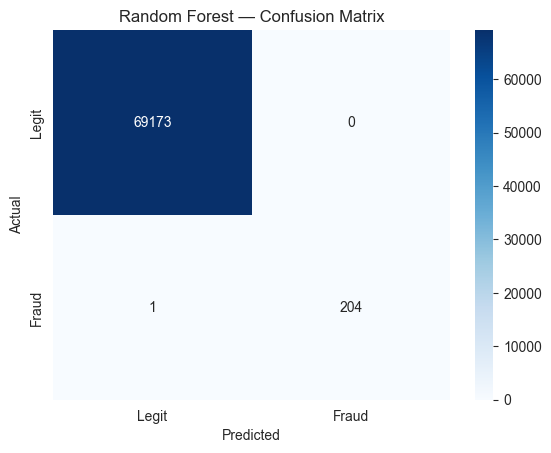

In [7]:
from sklearn.metrics import confusion_matrix
pred = models['rf'].predict(X_te)
cm = confusion_matrix(y_te, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Random Forest — Confusion Matrix')
plt.show()

## 9. Feature Importance
Which features drive the predictions?

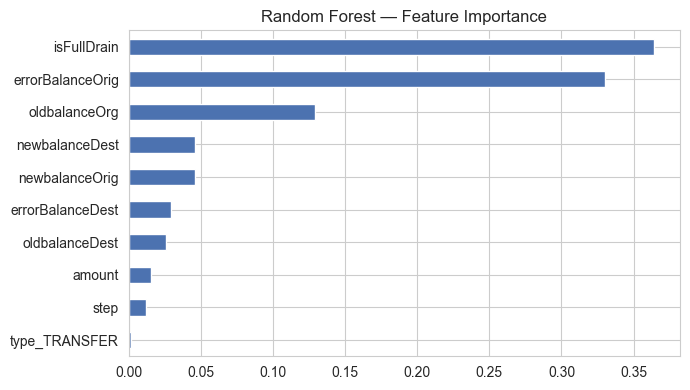

isFullDrain         0.363938
errorBalanceOrig    0.329882
oldbalanceOrg       0.128855
newbalanceDest      0.046300
newbalanceOrig      0.045917
dtype: float64


In [8]:
imp = pd.Series(models['rf'].feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', figsize=(7,4), color='#4C72B0')
plt.title('Random Forest — Feature Importance'); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).head())

## 10. Results & Honest Interpretation

**All three models score near-perfectly (Recall ~0.99, PR-AUC ~0.99).**

This is **expected and worth stating openly in the report**:

- PaySim is *synthetic*. Its fraud follows a near-mechanical pattern: fraud almost always **drains the sender's account** (`isFullDrain`) and **breaks balance reconciliation** (`errorBalanceOrig`). Together these two engineered features drive ~69% of the model's decisions.
- Real-world fraud is messier and would not separate this cleanly. These scores demonstrate a **sound methodology on clean synthetic data**, not that fraud detection is solved.

**What this project genuinely demonstrates:**
1. Correct handling of severe class imbalance (metrics, weighting, split order).
2. Feature engineering that exposes the fraud signal.
3. A reproducible train → evaluate → compare pipeline across three models.

**Model choice:** Random Forest and XGBoost tie on F1 (1.0 precision, 0.995 recall). Random Forest is the simpler pick; XGBoost is more scalable. Either is defensible.